In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from blackhole.constants import M_sun, ALPHA_COLD, ALPHA_HOT
from blackhole.parameter_evaluation import ParameterEvaluation

# Parameter Evaluation

Pre-flight checks for DIM simulation parameters. Verifies two critical constraints
before committing to a multi-hour run:

1. **Mass deposition** — `dt_used < dt_max`: if violated, `add_mass` silently skips
   deposition and the disk stays empty.
2. **DIM instability** — `Sigma_ss / Sigma_max > threshold`: if the cold-disk
   steady-state surface density is too low, the disk never outbursts.

Edit the parameters in the cells below and run to check your configuration.

---
## 1. User Parameters

Edit these values to match your simulation setup.

In [2]:
# ---------------------------------------------------------------------------
# Physical parameters (edit these)
# ---------------------------------------------------------------------------
M_star = 9 * M_sun     # Central object mass (g)
R_1    = 5e8            # Inner disk radius (cm)
R_K    = 2.2e11         # Circularisation / mass transfer radius (cm)
R_N    = 4.2e11         # Outer disk radius (cm)
M_dot  = 1e17           # Mass transfer rate (g/s)

# Viscosity parameters
alpha_cold = ALPHA_COLD  # Cold-state alpha (default 0.04)
alpha_hot  = ALPHA_HOT   # Hot-state alpha (default 0.2)

# Grid parameters
N   = 100               # Number of base grid cells
N_n = 3                 # Extra boundary cells (notebook convention)

# Cold-disk temperature for viscosity estimate
T_cold = 1000.0         # K

# Instability threshold (0.3 allows for local accumulation triggering outbursts)
instability_threshold = 0.3

# ---------------------------------------------------------------------------
# Timestep configuration (edit these)
# ---------------------------------------------------------------------------
dt_mult  = 30           # CFL timestep multiplier
dt_floor = 200.0        # Minimum timestep (s), 0 to disable
dt_cap   = None          # Maximum timestep (s), None to disable

---
## 2. Evaluate

In [3]:
pe = ParameterEvaluation(
    M_star=M_star, R_1=R_1, R_K=R_K, R_N=R_N, M_dot=M_dot,
    alpha_cold=alpha_cold, alpha_hot=alpha_hot,
    N=N, N_n=N_n, T_cold=T_cold,
    instability_threshold=instability_threshold,
)
result = pe.evaluate(dt_mult=dt_mult, dt_floor=dt_floor, dt_cap=dt_cap)

# ---------------------------------------------------------------------------
# Summary
# ---------------------------------------------------------------------------
status = "PASS" if result.valid else "FAIL"
print(f"{'='*60}")
print(f"  Parameter Evaluation: {status}")
print(f"{'='*60}")
print()

dep_status = "OK" if result.mass_deposition_ok else "FAIL"
inst_status = "OK" if result.instability_ok else "FAIL"

print(f"  Mass deposition:  [{dep_status}]  margin = {result.deposition_margin:.1f}x")
print(f"    dt_used = {result.dt_used:.2e} s,  dt_max = {result.dt_max:.2e} s")
print()
print(f"  DIM instability:  [{inst_status}]  ratio  = {result.instability_ratio:.3f}")
print(f"    Sigma_ss = {result.sigma_ss:.1f} g/cm^2,  Sigma_max = {result.sigma_max:.1f} g/cm^2")
print()
print(f"  Timestep:  dt_cfl = {result.dt_cfl:.2e} s  ->  dt_used = {result.dt_used:.2e} s")
print(f"  Viscous timescale at R_K:  t_visc = {result.t_viscous:.2e} s  ({result.t_viscous / 3.156e7:.1f} yr)")
print(f"{'='*60}")

  Parameter Evaluation: PASS

  Mass deposition:  [OK]  margin = 1551.0x
    dt_used = 1.06e+04 s,  dt_max = 1.64e+07 s

  DIM instability:  [OK]  ratio  = 0.365
    Sigma_ss = 807.2 g/cm^2,  Sigma_max = 2211.6 g/cm^2

  Timestep:  dt_cfl = 3.52e+02 s  ->  dt_used = 1.06e+04 s
  Viscous timescale at R_K:  t_visc = 3.68e+09 s  (116.7 yr)


---
## 3. Reference Configurations

Evaluate all 7 notebook configurations for comparison.

In [4]:
# ---------------------------------------------------------------------------
# Reference configurations from the 7 simulation notebooks
# ---------------------------------------------------------------------------
configs = {
    "WD": dict(
        M_star=M_sun, R_1=5e8, R_K=2.1e10, R_N=8e10,
        M_dot=5e16, alpha_cold=0.04,
        dt_mult=10, dt_floor=200,
    ),
    "BH base": dict(
        M_star=9*M_sun, R_1=5e8, R_K=2.2e11, R_N=4.2e11,
        M_dot=3e17, alpha_cold=0.04,
        dt_mult=30, dt_floor=200,
    ),
    "BH noeffects": dict(
        M_star=9*M_sun, R_1=5e8, R_K=2.2e11, R_N=4.2e11,
        M_dot=1e17, alpha_cold=0.04,
        dt_mult=30, dt_floor=200,
    ),
    "BH irrad": dict(
        M_star=9*M_sun, R_1=5e8, R_K=2.2e11, R_N=4.2e11,
        M_dot=1e17, alpha_cold=0.04,
        dt_mult=30, dt_floor=200,
    ),
    "BH evap": dict(
        M_star=9*M_sun, R_1=5e8, R_K=2.2e11, R_N=4.2e11,
        M_dot=1e17, alpha_cold=0.04,
        dt_mult=100, dt_floor=200,
    ),
    "BH irrad+evap": dict(
        M_star=9*M_sun, R_1=5e8, R_K=2.2e11, R_N=4.2e11,
        M_dot=1e17, alpha_cold=0.04,
        dt_mult=30, dt_floor=200,
    ),
    "Sgr A*": dict(
        M_star=4.3e6*M_sun, R_1=4e12, R_K=1e15, R_N=2e15,
        M_dot=1e22, alpha_cold=0.02,
        dt_mult=300, dt_floor=1e5, dt_cap=2e9,
    ),
}

# Evaluate all
ref_results = {}
for name, cfg in configs.items():
    pe_ref = ParameterEvaluation(
        M_star=cfg["M_star"], R_1=cfg["R_1"], R_K=cfg["R_K"], R_N=cfg["R_N"],
        M_dot=cfg["M_dot"], alpha_cold=cfg.get("alpha_cold", ALPHA_COLD),
    )
    ref_results[name] = pe_ref.evaluate(
        dt_mult=cfg["dt_mult"],
        dt_floor=cfg.get("dt_floor", 0),
        dt_cap=cfg.get("dt_cap", None),
    )

# Print table
print(f"{'Config':<16} {'Valid':>5}  {'Dep OK':>6}  {'Margin':>8}  {'Inst OK':>7}  {'Ratio':>7}  {'Sigma_ss':>10}  {'Sigma_max':>10}")
print("-" * 90)
for name, r in ref_results.items():
    v = "PASS" if r.valid else "FAIL"
    d = "OK" if r.mass_deposition_ok else "FAIL"
    i = "OK" if r.instability_ok else "FAIL"
    print(f"{name:<16} {v:>5}  {d:>6}  {r.deposition_margin:>7.1f}x  {i:>7}  {r.instability_ratio:>7.3f}  {r.sigma_ss:>10.1f}  {r.sigma_max:>10.1f}")

Config           Valid  Dep OK    Margin  Inst OK    Ratio    Sigma_ss   Sigma_max
------------------------------------------------------------------------------------------
WD                PASS      OK    163.8x       OK   12.409      4561.4       367.6
BH base           PASS      OK    517.0x       OK    1.095      2421.7      2211.6
BH noeffects      PASS      OK   1551.0x       OK    0.365       807.2      2211.6
BH irrad          PASS      OK   1551.0x       OK    0.365       807.2      2211.6
BH evap           PASS      OK    465.3x       OK    0.365       807.2      2211.6
BH irrad+evap     PASS      OK   1551.0x       OK    0.365       807.2      2211.6
Sgr A*            PASS      OK      1.7x       OK    1.012    364144.5    359894.5


---
## 4. Timestep Multiplier Scan

Sweep `dt_mult` to find the safe range for the user's parameters.

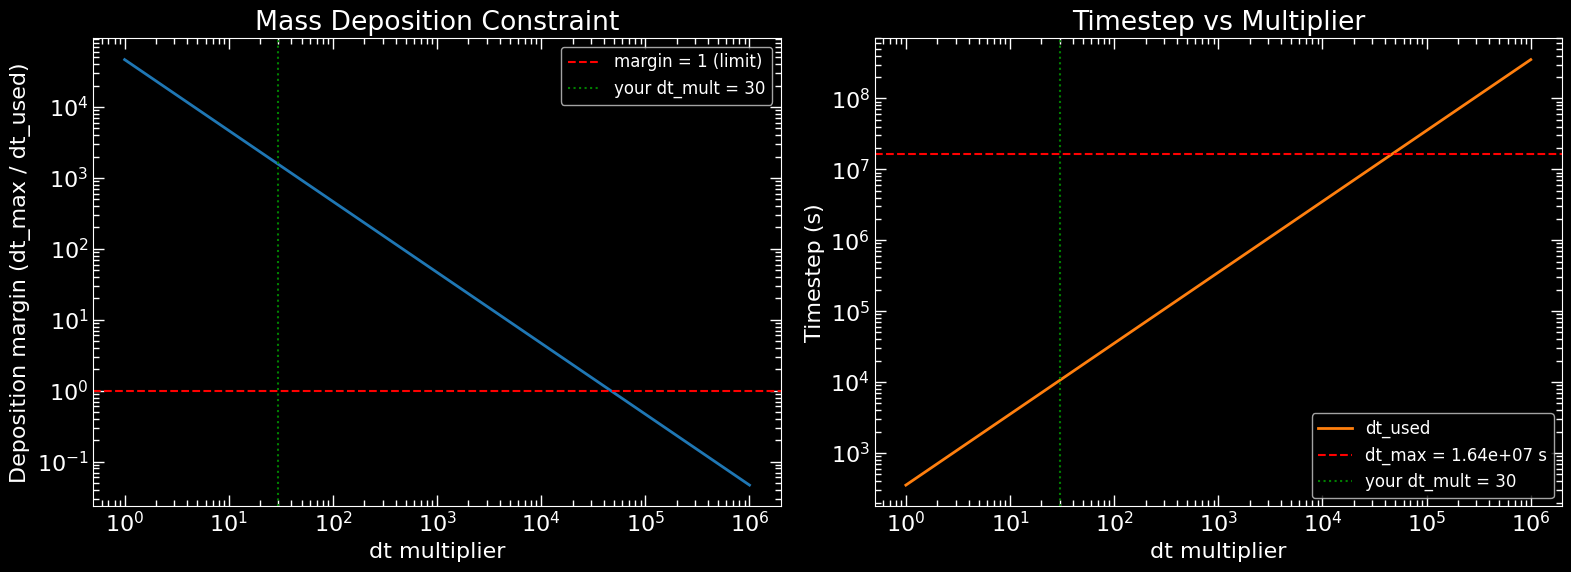


Critical dt_mult (margin=1): ~47138
Your dt_mult (30) is 1571x below the limit.


In [5]:
# Rebuild ParameterEvaluation from user parameters (cell 2)
pe_scan = ParameterEvaluation(
    M_star=M_star, R_1=R_1, R_K=R_K, R_N=R_N, M_dot=M_dot,
    alpha_cold=alpha_cold, alpha_hot=alpha_hot,
    N=N, N_n=N_n, T_cold=T_cold,
    instability_threshold=instability_threshold,
)

mults = np.logspace(0, 6, 200)
margins = np.array([pe_scan.evaluate(m, dt_floor=dt_floor, dt_cap=dt_cap).deposition_margin for m in mults])
dt_used_arr = np.array([pe_scan.evaluate(m, dt_floor=dt_floor, dt_cap=dt_cap).dt_used for m in mults])

# Find critical multiplier where margin = 1
crit_idx = np.searchsorted(-margins, -1.0)  # first index where margin < 1
crit_mult = mults[crit_idx] if crit_idx < len(mults) else mults[-1]

font = {'weight': 'normal', 'size': 16}
plt.rc('font', **font)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: deposition margin vs dt_mult
ax1.loglog(mults, margins, linewidth=2, color='tab:blue')
ax1.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='margin = 1 (limit)')
ax1.axvline(dt_mult, color='green', linestyle=':', linewidth=1.5, label=f'your dt_mult = {dt_mult}')
ax1.set_xlabel('dt multiplier')
ax1.set_ylabel('Deposition margin (dt_max / dt_used)')
ax1.set_title('Mass Deposition Constraint')
ax1.legend(fontsize=12)
ax1.minorticks_on()
ax1.tick_params(axis='both', which='major', direction='in', length=8, width=1)
ax1.tick_params(axis='both', which='minor', direction='in', length=4, width=1)
ax1.tick_params(axis='both', which='both', top=True, right=True, direction='in')

# Right: dt_used vs dt_mult
ax2.loglog(mults, dt_used_arr, linewidth=2, color='tab:orange', label='dt_used')
r0 = pe_scan.evaluate(dt_mult, dt_floor=dt_floor, dt_cap=dt_cap)
ax2.axhline(r0.dt_max, color='red', linestyle='--', linewidth=1.5, label=f'dt_max = {r0.dt_max:.2e} s')
ax2.axvline(dt_mult, color='green', linestyle=':', linewidth=1.5, label=f'your dt_mult = {dt_mult}')
ax2.set_xlabel('dt multiplier')
ax2.set_ylabel('Timestep (s)')
ax2.set_title('Timestep vs Multiplier')
ax2.legend(fontsize=12)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='major', direction='in', length=8, width=1)
ax2.tick_params(axis='both', which='minor', direction='in', length=4, width=1)
ax2.tick_params(axis='both', which='both', top=True, right=True, direction='in')

plt.tight_layout()
plt.savefig('../graphs/parameter_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCritical dt_mult (margin=1): ~{crit_mult:.0f}")
print(f"Your dt_mult ({dt_mult}) is {crit_mult/dt_mult:.0f}x below the limit.")

---
## 5. M_dot Sensitivity

Sweep `M_dot` to see how the instability ratio changes, keeping all other parameters fixed.

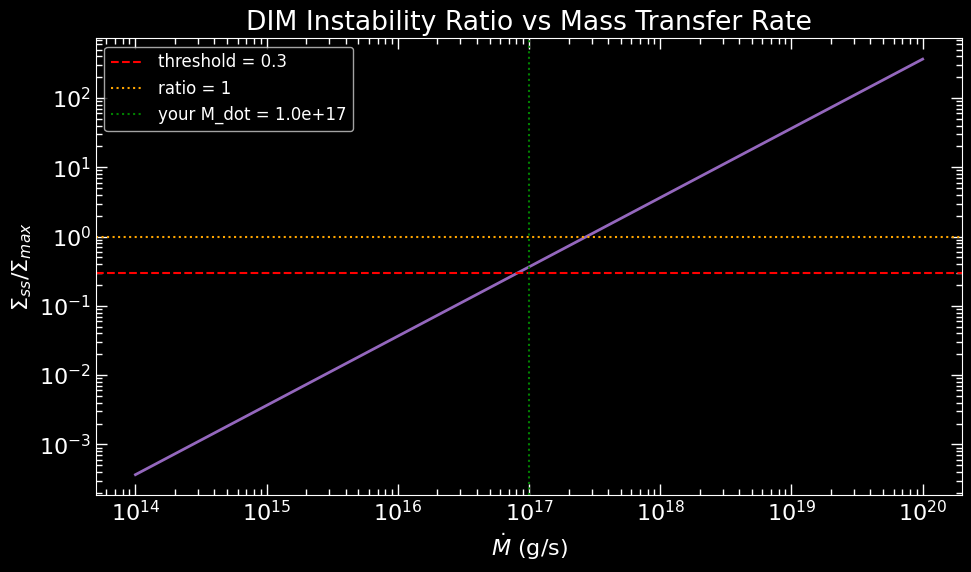

Minimum M_dot for instability (ratio > 0.3): ~8.41e+16 g/s
Your M_dot (1.0e+17) gives ratio = 0.365


In [6]:
mdots = np.logspace(np.log10(M_dot) - 3, np.log10(M_dot) + 3, 200)
ratios = []
for md in mdots:
    pe_md = ParameterEvaluation(
        M_star=M_star, R_1=R_1, R_K=R_K, R_N=R_N, M_dot=md,
        alpha_cold=alpha_cold, alpha_hot=alpha_hot,
        N=N, N_n=N_n, T_cold=T_cold,
    )
    ratios.append(pe_md.evaluate(dt_mult).instability_ratio)
ratios = np.array(ratios)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(mdots, ratios, linewidth=2, color='tab:purple')
ax.axhline(instability_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'threshold = {instability_threshold}')
ax.axhline(1.0, color='orange', linestyle=':', linewidth=1.5, label='ratio = 1')
ax.axvline(M_dot, color='green', linestyle=':', linewidth=1.5,
           label=f'your M_dot = {M_dot:.1e}')
ax.set_xlabel(r'$\dot{M}$ (g/s)')
ax.set_ylabel(r'$\Sigma_{ss} / \Sigma_{max}$')
ax.set_title('DIM Instability Ratio vs Mass Transfer Rate')
ax.legend(fontsize=12)
ax.minorticks_on()
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1)
ax.tick_params(axis='both', which='both', top=True, right=True, direction='in')
plt.tight_layout()
plt.show()

# Find critical M_dot where ratio = threshold
crit_mdot_idx = np.searchsorted(ratios, instability_threshold)
if 0 < crit_mdot_idx < len(mdots):
    print(f"Minimum M_dot for instability (ratio > {instability_threshold}): ~{mdots[crit_mdot_idx]:.2e} g/s")
print(f"Your M_dot ({M_dot:.1e}) gives ratio = {result.instability_ratio:.3f}")